In this notebook, all filters are applied to the Kitti dataset to make sure the pose estimation of all the filters in 3d work as intended.

In [1]:
import os
import sys
import numpy as np
sys.path.append('/app/src')
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, FilterEnum
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm


%matplotlib inline
np.random.seed(777)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


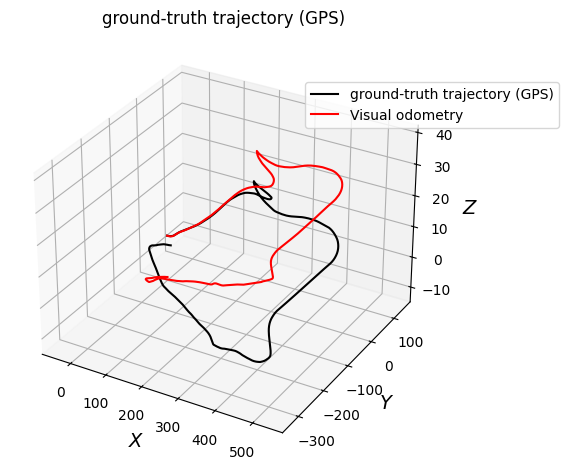

In [2]:
root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0033'
dimension=3

data = DataLoader(
  sequence_nr=kitti_drive, 
  kitti_root_dir=kitti_root_dir, 
  noise_vector_dir=noise_vector_dir,
  vo_dropout_ratio=0.0, 
  gps_dropout_ratio=0.0,
  visualize_data=True,
  dimension=dimension
)

# Apply filters

------

## Setup1 (IMU, VO)

In [15]:
setup = SetupEnum.SETUP_1
measurement_type = MeasurementDataEnum.ALL_DATA

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF)
ekf1_0 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

alpha_setup1_0 = 1.
beta_setup1_0 = 2.
kappa_setup1_0 = 0.
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF)
ukf1_0 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_0, 
  beta=beta_setup1_0, 
  kappa=kappa_setup1_0,
  setup=setup
)

n_samples_setup1_0=2048
resampling_algorithm_setup1_0=ResamplingAlgorithms.STRATIFIED
importance_resampling = True
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF)
pf1_0 = ParticleFilter(
  N=n_samples_setup1_0, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_0
)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())


n_ensemble_setup1_0=64
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF)
enkf1_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_0, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF)
ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [16]:
error_ekf1_0 = ekf1_0.run(data=data, debug_mode=True)
error_ukf1_0 = ukf1_0.run(data=data, debug_mode=True)
error_pf1_0 = pf1_0.run(data=data, importance_resampling=importance_resampling, debug_mode=True)
error_enkf1_0 = enkf1_0.run(data=data, debug_mode=True)
error_ckf1_0 = ckf1_0.run(data=data, debug_mode=True)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 8857.00it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 6.517 m
Root Mean Squared Error: 9.254 m
Maximum Error: 25.554 m
---------------------------------------------------

[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2340.01it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 5.961 m
Root Mean Squared Error: 8.156 m
Maximum Error: 25.294 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 6.385 m
Root Mean Squared Error: 8.999 m
Maximum Error: 25.082 m
--------------------------------------------------

[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1058.57it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 6.542 m
Root Mean Squared Error: 9.143 m
Maximum Error: 27.175 m
----------------------------------------------------

[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2395.94it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 6.204 m
Root Mean Squared Error: 8.66 m
Maximum Error: 24.211 m
---------------------------------------------------



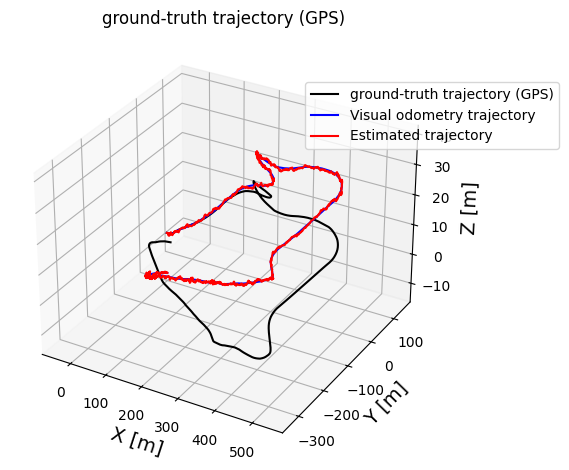

In [17]:
ekf1_0.visualize_trajectory(data=data, dimension=dimension, interval=1)

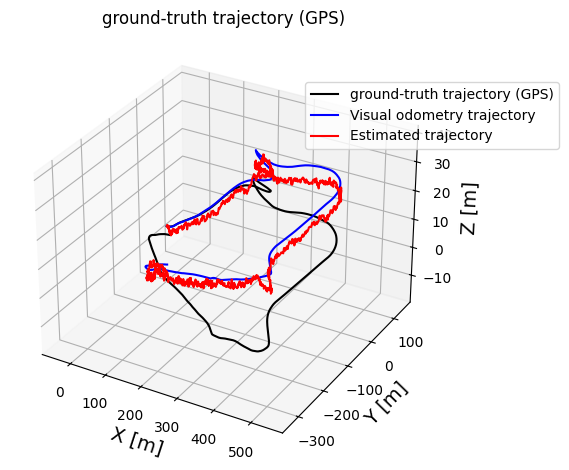

In [18]:
ukf1_0.visualize_trajectory(data=data, dimension=dimension, interval=1)

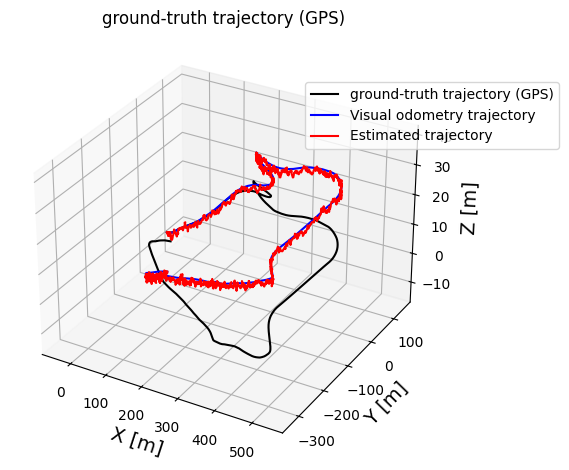

In [19]:
pf1_0.visualize_trajectory(data=data, dimension=dimension, interval=1)

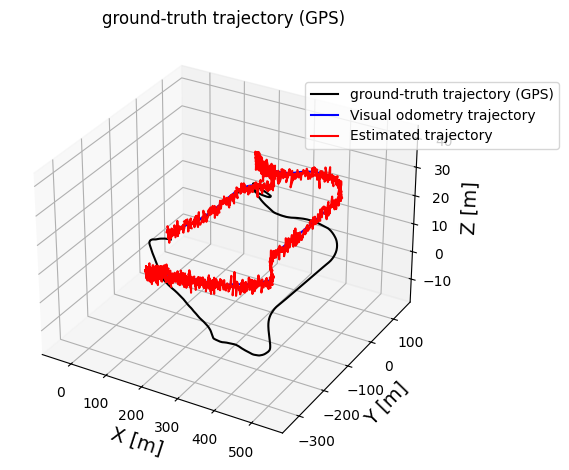

In [20]:
enkf1_0.visualize_trajectory(data=data, dimension=dimension, interval=1)

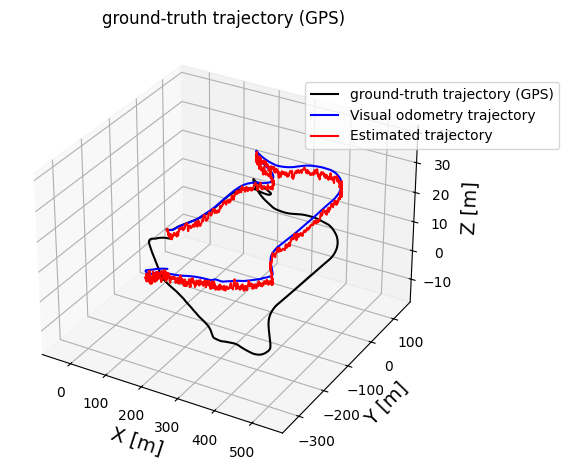

In [21]:
ckf1_0.visualize_trajectory(data=data, dimension=dimension, interval=1)

## Setup2 (IMU, VO + GPS)

In [22]:
setup = SetupEnum.SETUP_2
measurement_type = MeasurementDataEnum.ALL_DATA

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF)
ekf2_0 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

alpha_setup2_0 = 1.
beta_setup2_0 = 2.0
kappa_setup2_0 = 0.0
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF)
ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=setup
)

n_samples_setup2_0 = 2048
resampling_algorithm_setup2_0 = ResamplingAlgorithms.STRATIFIED
importance_resampling = True
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF)
pf2_0 = ParticleFilter(
  N=n_samples_setup2_0, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_0
)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

n_ensemble_setup2_0 = 64
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF)
enkf2_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_0, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF)
ckf2_0 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [23]:
error_ekf2_0 = ekf2_0.run(data=data, debug_mode=True)
error_ukf2_0 = ukf2_0.run(data=data, debug_mode=True)
error_pf2_0 = pf2_0.run(data=data, importance_resampling=importance_resampling, debug_mode=True)
error_enkf2_0 = enkf2_0.run(data=data, debug_mode=True)
error_ckf2_0 = ckf2_0.run(data=data, debug_mode=True)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 9330.51it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.673 m
Root Mean Squared Error: 0.859 m
Maximum Error: 3.364 m
-------------------------------------------------------

[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 1797.47it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.94 m
Root Mean Squared Error: 2.538 m
Maximum Error: 8.585 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 10500.712 m
Root Mean Squared Error: 25029.886 m
Maximum Error: 103293.354 m
------------------------------------------------------

[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 767.30it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.583 m
Root Mean Squared Error: 2.049 m
Maximum Error: 10.974 m
--------------------------------------------------------

[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 1879.84it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.838 m
Root Mean Squared Error: 2.44 m
Maximum Error: 7.322 m
-------------------------------------------------------



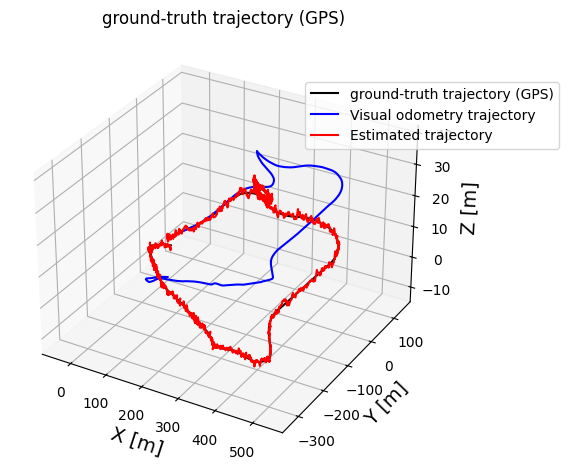

In [24]:
ekf2_0.visualize_trajectory(data=data, dimension=dimension, interval=1)

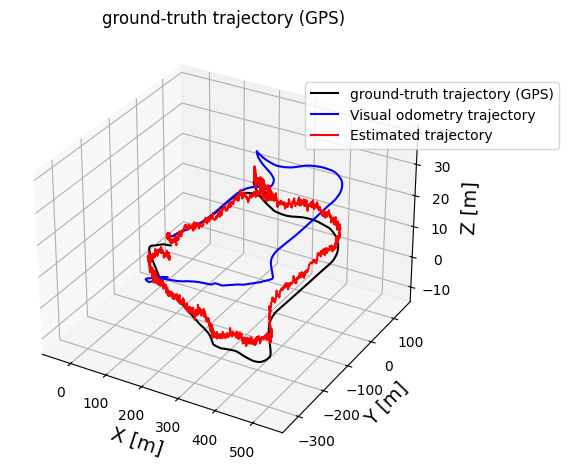

In [25]:
ukf2_0.visualize_trajectory(data=data, dimension=dimension, interval=1)

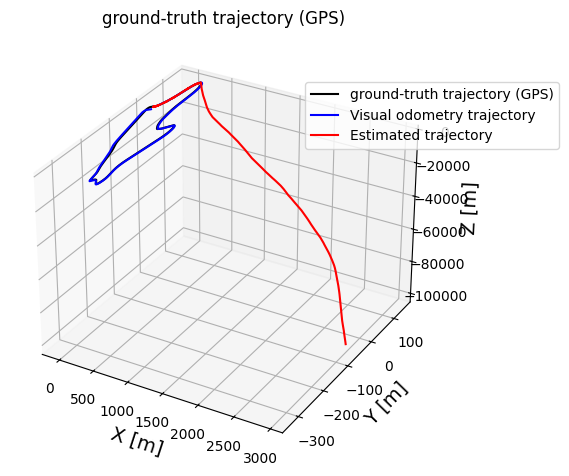

In [26]:
pf2_0.visualize_trajectory(data=data, dimension=dimension, interval=1)

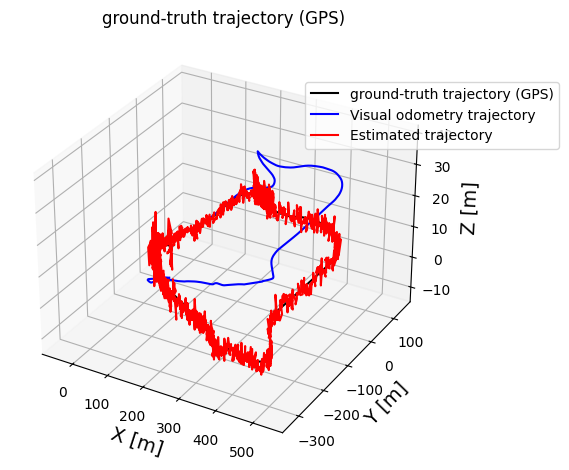

In [27]:
enkf2_0.visualize_trajectory(data=data, dimension=dimension, interval=1)

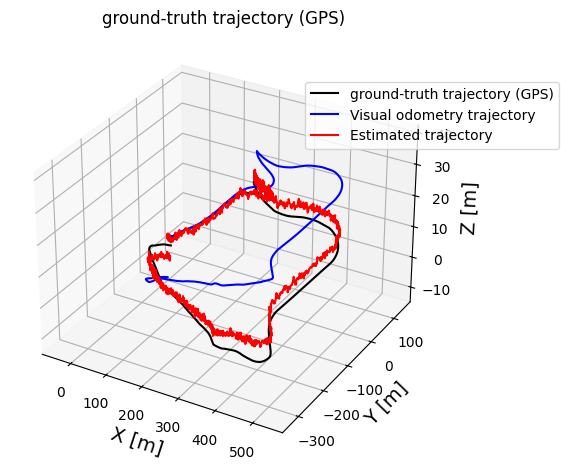

In [28]:
ckf2_0.visualize_trajectory(data=data, dimension=dimension, interval=1)

## Conclusion

In this notebook, implemented filters are applied to the KITTI raw dataset sequence number 09 for two setups, Setup1(IMU, VO) and Setup2(IMU, VO+GPS), and estimated result is computed in 3D.

Overall, most of the filters provide estimations as intended except the Particle Filter, which may requires more number of samples to prevent filter divergence occurs in the process.